In [58]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42

## Filtered dataset as how FWC implemented it:

In [59]:
allmeta = pd.read_csv("../030426_all_sample_data.tabular", sep = "\t")

In [60]:
allmeta.loc[allmeta["Colony Latitude"] == "-9", "Colony Latitude"] = np.nan
allmeta.loc[allmeta["Colony Longitude"] == "-9", "Colony Longitude"] = np.nan
allmeta.loc[allmeta["Reef Latitude"] == "-9", "Reef Latitude"] = np.nan
allmeta.loc[allmeta["Reef Longitude"] == "-9", "Reef Longitude"] = np.nan
allmeta.loc[allmeta["Colony Latitude"] == -9, "Colony Latitude"] = np.nan
allmeta.loc[allmeta["Colony Longitude"] == -9, "Colony Longitude"] = np.nan
allmeta.loc[allmeta["Reef Latitude"] == -9, "Reef Latitude"] = np.nan
allmeta.loc[allmeta["Reef Longitude"] == -9, "Reef Longitude"] = np.nan
allmeta.loc[allmeta["Colony Latitude"].notna(), "Latitude"] = allmeta["Colony Latitude"]
allmeta.loc[allmeta["Colony Longitude"].notna(), "Longitude"] = allmeta["Colony Longitude"]
allmeta.loc[allmeta["Colony Latitude"].isna(), "Latitude"] = allmeta["Reef Latitude"]
allmeta.loc[allmeta["Colony Longitude"].isna(), "Longitude"] = allmeta["Reef Longitude"]
allmeta["Latitude"] = allmeta["Latitude"].astype(float)
allmeta["Longitude"] = allmeta["Longitude"].astype(float)
allmeta.loc[allmeta["Reef Name"] == "LaBarrera", "Latitude"] = 21.132540
allmeta.loc[allmeta["Reef Name"] == "LaBarrera", "Longitude"] = -86.690370
allmeta.loc[allmeta["Sample ID"] == "A12650", "Latitude"] = 24.632895
allmeta.loc[allmeta["Sample ID"] == "A12650", "Longitude"] = -81.096224
allmeta.loc[allmeta["Sample ID"] == "A10928", "Latitude"] = 25.281759
allmeta.loc[allmeta["Sample ID"] == "A10928", "Longitude"] = -80.209001
allmeta.loc[allmeta["Sample ID"] == "A10930", "Latitude"] = 25.220647
allmeta.loc[allmeta["Sample ID"] == "A10930", "Longitude"] = -80.211482
allmeta.loc[allmeta["Sample ID"] == "A10932", "Latitude"] = 25.139892
allmeta.loc[allmeta["Sample ID"] == "A10932", "Longitude"] = -80.294608
allmeta.loc[allmeta["Longitude"] == 68.570230, "Longitude"] = -68.570230
allmeta.loc[allmeta["Longitude"] == 68.575986, "Longitude"] = -68.575986
allmeta.loc[allmeta["Longitude"] == 86.511570, "Longitude"] = -86.511570

In [61]:
allmeta.loc[allmeta["Reef Name"] == "Veracruz", "Region"] = "Mexico"

In [62]:
allmeta = (allmeta[allmeta["Region"] != "State College"]
           [allmeta["Genetic Coral Species Call"] == "A.palmata"]
           [~allmeta["Reef Name"].str.contains("batch", case = False)]
           [~allmeta["Reef Name"].str.contains("cross", case = False)]
           [~allmeta["Reef Name"].str.contains("sexual", case = False)].reset_index(drop=True))

/fs/s6k/fast/scratch/16475825_noge4093_mpcs055/ipykernel_237422/3756135735.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  allmeta = (allmeta[allmeta["Region"] != "State College"]
/fs/s6k/fast/scratch/16475825_noge4093_mpcs055/ipykernel_237422/3756135735.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  allmeta = (allmeta[allmeta["Region"] != "State College"]
/fs/s6k/fast/scratch/16475825_noge4093_mpcs055/ipykernel_237422/3756135735.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  allmeta = (allmeta[allmeta["Region"] != "State College"]
/fs/s6k/fast/scratch/16475825_noge4093_mpcs055/ipykernel_237422/3756135735.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  allmeta = (allmeta[allmeta["Region"] != "State College"]


In [63]:
allmeta[["Affymetrix ID"]].to_csv("../fwc_samples.txt", index = False, header = None)

In [388]:
%%bash
source ~/.bashrc
conda activate orbicella
##some of the samples won't be in the dataset since the vcf only contains unique genotypes, so we'll use --force-samples
bcftools view ../030426_stagdb_allgenotypes.vcf.gz \
    -S ../fwc_samples.txt \
    --force-samples \
    -O z > ../filtered_calls/fwc_filtered.vcf.gz

Warn: subset called for sample that does not exist in header: "120207013_(Axiom_AcropSNP)_A03.CEL"... skipping
Warn: subset called for sample that does not exist in header: "120207014_(Axiom_AcropSNP)_A05.CEL"... skipping
Warn: subset called for sample that does not exist in header: "120207016_(Axiom_AcropSNP)_A09.CEL"... skipping
Warn: subset called for sample that does not exist in header: "120207017_(Axiom_AcropSNP)_A11.CEL"... skipping
Warn: subset called for sample that does not exist in header: "120207018_(Axiom_AcropSNP)_A13.CEL"... skipping
Warn: subset called for sample that does not exist in header: "120207019_(Axiom_AcropSNP)_A15.CEL"... skipping
Warn: subset called for sample that does not exist in header: "120207020_(Axiom_AcropSNP)_A17.CEL"... skipping
Warn: subset called for sample that does not exist in header: "120207022_(Axiom_AcropSNP)_A21.CEL"... skipping
Warn: subset called for sample that does not exist in header: "120207025_(Axiom_AcropSNP)_C03.CEL"... skipping
W

In [64]:
%%bash
source ~/.bashrc
conda activate orbicella
plink2 --vcf ../filtered_calls/fwc_filtered.vcf.gz \
    --king-cutoff 0.354

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to plink2.log.
Options in effect:
  --king-cutoff 0.354
  --vcf ../filtered_calls/fwc_filtered.vcf.gz

Start time: Wed Apr 29 16:23:01 2026
771373 MiB RAM detected, ~684525 available; reserving 385686 MiB for main
workspace.
Using up to 8 compute threads.
--vcf: 53589 variants scanned.
--vcf: plink2-temporary.pgen + plink2-temporary.pvar.zst +
plink2-temporary.psam written.
1287 samples (0 females, 0 males, 1287 ambiguous; 1287 founders) loaded from
plink2-temporary.psam.
Note: 1431 nonstandard chromosome codes present.
53589 variants loaded from plink2-temporary.pvar.zst.
Note: No phenotype data present.
--king-cutoff pass 1/1: Scanning for rare variants... done.
11085 variants handled by initial scan (42504 remaining).
--king-cutoff pass 1/1: Condensing...               done.
--king-cutoff: 53589 variants processed.
--ki

In [65]:
%%bash
source ~/.bashrc
conda activate orbicella
bcftools view ../filtered_calls/fwc_filtered.vcf.gz \
    -S plink2.king.cutoff.in.id --force-samples \
    | bcftools view -q 0.05:minor \
    -m2 -M2 -v snps \
    -O z > ../filtered_calls/fwc_maffiltered.vcf.gz

Warn: subset called for sample that does not exist in header: "#IID"... skipping
Warn: subset called for sample that does not exist in header: "AP368"... skipping
Warn: subset called for sample that does not exist in header: "AP369"... skipping
Warn: subset called for sample that does not exist in header: "AP370"... skipping
Warn: subset called for sample that does not exist in header: "AP371"... skipping
Warn: subset called for sample that does not exist in header: "AP372"... skipping
Warn: subset called for sample that does not exist in header: "AP373"... skipping
Warn: subset called for sample that does not exist in header: "AP374"... skipping
Warn: subset called for sample that does not exist in header: "AP40"... skipping
Warn: subset called for sample that does not exist in header: "Sarah"... skipping


In [66]:
%%bash
source ~/.bashrc
conda activate orbicella
plink2 --vcf ../filtered_calls/fwc_maffiltered.vcf.gz \
    --pca 200 --out fwc

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to fwc.log.
Options in effect:
  --out fwc
  --pca 200
  --vcf ../filtered_calls/fwc_maffiltered.vcf.gz

Start time: Wed Apr 29 16:24:34 2026
771373 MiB RAM detected, ~682138 available; reserving 385686 MiB for main
workspace.
Using up to 8 compute threads.
--vcf: 25362 variants scanned.
--vcf: fwc-temporary.pgen + fwc-temporary.pvar.zst + fwc-temporary.psam
written.
1268 samples (0 females, 0 males, 1268 ambiguous; 1268 founders) loaded from
fwc-temporary.psam.
Note: 1327 nonstandard chromosome codes present.
25362 variants loaded from fwc-temporary.pvar.zst.
Note: No phenotype data present.
Calculating allele frequencies... done.
Constructing GRM: 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656666676869707172737475767778798081828384858687888990919293949596

In [67]:
eigen = pd.read_csv("fwc.eigenvec", sep = "\t")

In [68]:
eigenval = pd.read_csv("fwc.eigenval", header = None)

In [69]:
eigenval[0] = (eigenval[0] / eigenval[0].sum()) * 100

In [70]:
allmeta["#IID"] = allmeta["Affymetrix ID"]

In [71]:
eigen = eigen.merge(allmeta, how = "left", on = "#IID")

In [72]:
eigen.loc[eigen["Reef Name"] == "Alacranes", "Region"] = "Mexico, Gulf Side"
eigen.loc[eigen["Reef Name"] == "Veracruz", "Region"] = "Mexico, Gulf Side"
eigen.loc[eigen["Reef Name"] == "Serrana", "Region"] = "Colombia, San Andres"
eigen.loc[eigen["Reef Name"] == "Roncador", "Region"] = "Colombia, San Andres"

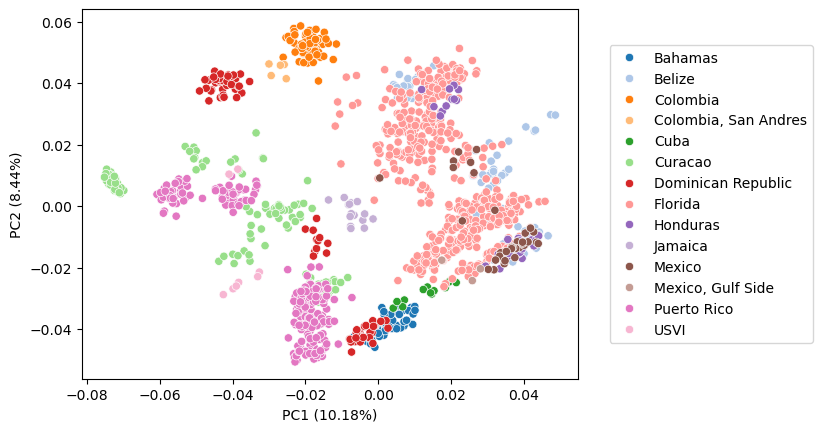

In [73]:
sns.scatterplot(data = eigen.sort_values("Region").reset_index(drop=True), 
                x = "PC1", y = "PC2", hue = "Region", palette = "tab20")
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.xlabel("PC1 (" + str(round(eigenval[0][0], 2)) + "%)")
plt.ylabel("PC2 (" + str(round(eigenval[0][1], 2)) + "%)")
plt.savefig("../figures/FigS1.pdf", dpi = 300)

## Filtered dataset for _actual_ popgen:

In [6]:
allmeta = pd.read_csv("../030426_all_sample_data.tabular", sep = "\t")
allmeta.loc[allmeta["Reef Name"] == "Veracruz", "Region"] = "Mexico" #Veracruz is in Mexico, not Belize...
allmeta = (allmeta
 [allmeta["Genetic Coral Species Call"] == "A.palmata"] # Only extracting APAL
 [~allmeta["User Specimen ID"].str.contains("SWSA")] #selfed samples from CU
 [allmeta["Region"] != "State College"] # State College implies uncertain or unknown location data, because we don't have Apal in State College...
 [allmeta["Coral Mlg Clonal ID"] != "HG1212"] #This sample has been shown to be wonky - a genet that spans FL and Cuba - Probably some mislabeling?
 [~allmeta["Affymetrix ID"].str.contains("a100000")]).reset_index(drop=True) #Seq derived samples - Often stand out on their own and should be removed

In [659]:
allmeta[["Affymetrix ID"]].to_csv("../apal_samples.txt", index = False, header = None)

In [3]:
!mkdir -p ../filtered_calls

In [660]:
%%bash
source ~/.bashrc
conda activate orbicella
##some of the samples won't be in the dataset since the vcf only contains unique genotypes, so we'll use --force-samples
bcftools view ../030426_stagdb_allgenotypes.vcf.gz \
    -S ../apal_samples.txt \
    --force-samples \
    --include ID==@../genotyping_probes.txt \
    -O z > ../filtered_calls/030426_stagdb_allgenotypes_filtered.vcf.gz

Warn: subset called for sample that does not exist in header: "120207013_(Axiom_AcropSNP)_A03.CEL"... skipping
Warn: subset called for sample that does not exist in header: "120207014_(Axiom_AcropSNP)_A05.CEL"... skipping
Warn: subset called for sample that does not exist in header: "120207016_(Axiom_AcropSNP)_A09.CEL"... skipping
Warn: subset called for sample that does not exist in header: "120207017_(Axiom_AcropSNP)_A11.CEL"... skipping
Warn: subset called for sample that does not exist in header: "120207018_(Axiom_AcropSNP)_A13.CEL"... skipping
Warn: subset called for sample that does not exist in header: "120207019_(Axiom_AcropSNP)_A15.CEL"... skipping
Warn: subset called for sample that does not exist in header: "120207020_(Axiom_AcropSNP)_A17.CEL"... skipping
Warn: subset called for sample that does not exist in header: "120207022_(Axiom_AcropSNP)_A21.CEL"... skipping
Warn: subset called for sample that does not exist in header: "120207025_(Axiom_AcropSNP)_C03.CEL"... skipping
W

In [175]:
%%bash
source ~/.bashrc
conda activate orbicella
bcftools view ../vcf_sort.USVI_TNC_kowens.vcf.gz \
    --include ID==@../genotyping_probes.txt \
    -O z > ../filtered_calls/vcf_sort.USVI_TNC_kowens_filtered.vcf.gz

In [665]:
%%bash
source ~/.bashrc
conda activate orbicella
bcftools index ../filtered_calls/vcf_sort.USVI_TNC_kowens_filtered.vcf.gz 
bcftools index ../filtered_calls/030426_stagdb_allgenotypes_filtered.vcf.gz

In [666]:
%%bash
source ~/.bashrc
conda activate orbicella
bcftools merge \
    ../filtered_calls/030426_stagdb_allgenotypes_filtered.vcf.gz \
    ../filtered_calls/vcf_sort.USVI_TNC_kowens_filtered.vcf.gz \
    -O z > ../filtered_calls/allsamples.vcf.gz

In [667]:
!zcat ../filtered_calls/allsamples.vcf.gz | grep -v "^#" | wc -l ; \
    zcat ../filtered_calls/allsamples.vcf.gz | grep "^#" | tail -1 | cut -f10- | sed "s/\t/\n/g" | wc -l

19696
1462


In [45]:
!cat ../cactus_liftover.sh

#!/bin/bash
#SBATCH --nodes=1
#SBATCH --ntasks=8
#SBATCH --mem=256GB
#SBATCH --time=08:00:00
#SBATCH --job-name=lifto
#SBATCH --partition=mpcs_hifmb.p

source ~/.bashrc
conda activate gatk
cd /fs/dss/work/noge4093/apal_popgen/jupyter_notebooks
gatk --java-options '-Xmx64G' LiftoverVcf \
    I=../filtered_calls/allsamples.vcf.gz \
    O=../filtered_calls/allsamples_lifted_to_jaAcrPala1.3.vcf.gz \
    CHAIN=/fs/dss/groups/agmarinecons/apal_reference_panel/apal_reference_panel/liftover_process/chains/adig_vs_apal.chain \
    RECOVER_SWAPPED_REF_ALT=true \
    REJECT=../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_rejected.vcf.gz \
    R=/fs/dss/groups/agmarinecons/apal_reference_panel/apal_reference_panel/references/GCF_964030605.1_jaAcrPala1.3_genomic.fna


In [671]:
!sbatch ../cactus_liftover.sh

Submitted batch job 15846027


In [673]:
!zcat ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3.vcf.gz | grep -v "^#" | wc -l ; \
    zcat ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3.vcf.gz | grep "^#" | tail -1 | cut -f10- | sed "s/\t/\n/g" | wc -l

18898
1462


In [674]:
%%bash
source ~/.bashrc
conda activate orbicella
bcftools +setGT ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3.vcf.gz \
    -- -t q -n . -i 'FMT/CONF>=0.01' \
    | bcftools view -i 'F_MISSING<0.1' -Oz > ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered.vcf.gz

Filled 695854 alleles


In [675]:
!zcat ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered.vcf.gz | grep -v "^#" | wc -l ; \
    zcat ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered.vcf.gz | grep "^#" | tail -1 | cut -f10- | sed "s/\t/\n/g" | wc -l

18258
1462


In [676]:
%%bash
source ~/.bashrc
conda activate orbicella
plink2 --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered.vcf.gz --missing --out ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered.log.
Options in effect:
  --missing
  --out ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered
  --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered.vcf.gz

Start time: Wed Mar 11 21:33:12 2026
771474 MiB RAM detected, ~507520 available; reserving 385737 MiB for main
workspace.
Using up to 8 compute threads.
--vcf: 18258 variants scanned.
--vcf: 9k variants converted.  
../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered-temporary.pgen
+
../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered-temporary.pvar.zst
+
../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered-temporary.psam
written.
1462 samples (0 females, 0 males, 1462 ambiguous; 1462 founders) loaded from
../filtered_calls/allsampl

In [9]:
imiss = pd.read_csv("../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered.smiss", sep = "\t").sort_values("F_MISS")

/fs/s6k/fast/scratch/16467200_noge4093_mpcs056/ipykernel_3373794/1341045668.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(imiss["F_MISS"])


<Axes: xlabel='F_MISS', ylabel='Density'>

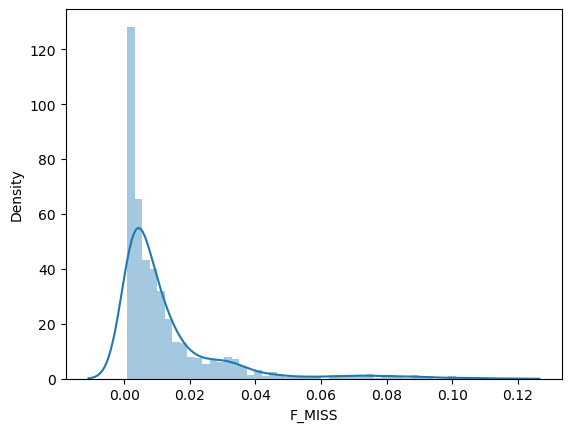

In [10]:
sns.distplot(imiss["F_MISS"])

In [11]:
imiss[["#IID"]][imiss["F_MISS"] > 0.05].to_csv("../filtered_calls/exclude_samples.txt", header = None, index = False)

In [ ]:
%%bash
source ~/.bashrc
conda activate orbicella
bcftools view -S ^../filtered_calls/exclude_samples.txt \
    ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered.vcf.gz -O z \
    > ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered.vcf.gz

In [3]:
!zcat ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered.vcf.gz | grep -v "^#" | wc -l ; \
    zcat ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered.vcf.gz | grep "^#" | tail -1 | cut -f10- | sed "s/\t/\n/g" | wc -l

18258
1397


In [14]:
%%bash
source ~/.bashrc
conda activate orbicella
plink2 --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered.vcf.gz \
    --make-king-table

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to plink2.log.
Options in effect:
  --make-king-table
  --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered.vcf.gz

Start time: Tue Apr 28 15:55:06 2026
771373 MiB RAM detected, ~726263 available; reserving 385686 MiB for main
workspace.
Using up to 8 compute threads.
--vcf: 18258 variants scanned.
--vcf: plink2-temporary.pgen + plink2-temporary.pvar.zst +
plink2-temporary.psam written.
1397 samples (0 females, 0 males, 1397 ambiguous; 1397 founders) loaded from
plink2-temporary.psam.
Note: 14 nonstandard chromosome codes present.
18258 variants loaded from plink2-temporary.pvar.zst.
Note: No phenotype data present.
--make-king-table pass 1/1: Scanning for rare variants... done.
9810 variants handled by initial scan (8448 remaining).
--make-king-table pass 1/1: Writing...                

In [15]:
%%bash
source ~/.bashrc
conda activate orbicella
plink2 --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered.vcf.gz \
    --king-cutoff 0.08834

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to plink2.log.
Options in effect:
  --king-cutoff 0.08834
  --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered.vcf.gz

Start time: Tue Apr 28 15:55:09 2026
771373 MiB RAM detected, ~726263 available; reserving 385686 MiB for main
workspace.
Using up to 8 compute threads.
--vcf: 18258 variants scanned.
--vcf: plink2-temporary.pgen + plink2-temporary.pvar.zst +
plink2-temporary.psam written.
1397 samples (0 females, 0 males, 1397 ambiguous; 1397 founders) loaded from
plink2-temporary.psam.
Note: 14 nonstandard chromosome codes present.
18258 variants loaded from plink2-temporary.pvar.zst.
Note: No phenotype data present.
--king-cutoff pass 1/1: Scanning for rare variants... done.
9818 variants handled by initial scan (8440 remaining).
--king-cutoff pass 1/1: Condensing...               do

Two samples get malformed names coming out of plink because of a whitespace (not supposed to be any whitespaces in STAGdb sample names but people make errors)...I'm going fix those here:

In [16]:
!zcat ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered.vcf.gz | grep "^#" | tail -1 | sed "s/\t/\n/g" | grep "Sarah"

Sarah 1_(Axiom_AcropSNP)_K07.CEL


In [17]:
!cat plink2.king.cutoff.in.id | grep "Sarah"

Sarah


In [18]:
!sed "s/Sarah/Sarah 1_(Axiom_AcropSNP)_K07.CEL/g" plink2.king.cutoff.in.id > fixed_plink2.king.cutoff.in.id

Also going to check for samples with anomalous heterozygosity and remove them if needed:

In [74]:
%%bash
source ~/.bashrc
conda activate orbicella
vcftools --gzvcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered.vcf.gz \
    --het --out ../filtered_calls/het


VCFtools - 0.1.16
(C) Adam Auton and Anthony Marcketta 2009

Parameters as interpreted:
	--gzvcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered.vcf.gz
	--het
	--out ../filtered_calls/het

Using zlib version: 1.2.13
After filtering, kept 1397 out of 1397 Individuals
Outputting Individual Heterozygosity
	Individual Heterozygosity: Only using biallelic SNPs.
After filtering, kept 18258 out of a possible 18258 Sites
Run Time = 6.00 seconds


/fs/s6k/fast/scratch/16467200_noge4093_mpcs056/ipykernel_3373794/3756081125.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(het["HET"])


<Axes: xlabel='HET', ylabel='Density'>

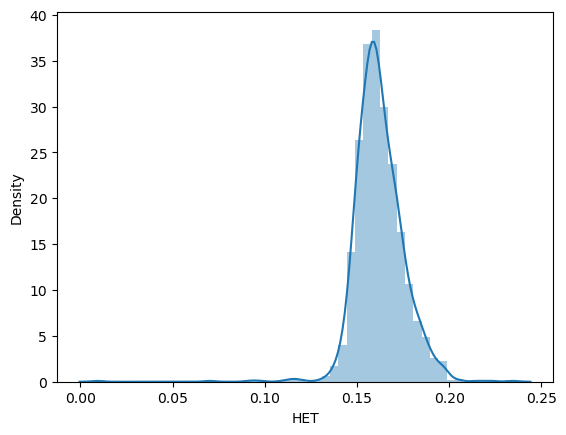

In [20]:
het = pd.read_csv("../filtered_calls/het.het", sep = "\t")
het["HET"] = (het["N_SITES"] - het["O(HOM)"]) / het["N_SITES"]
sns.distplot(het["HET"])

In [21]:
het[["INDV"]][het["HET"] < (het.HET.mean() - (het.HET.std()*3))].to_csv("../low_het_samps.txt", header = None, index = False)

In [2]:
!wc -l ../low_het_samps.txt

9 ../low_het_samps.txt


In [22]:
!grep -v -f ../low_het_samps.txt \
    fixed_plink2.king.cutoff.in.id \
    > fixed_nolowhet_plink2.king.cutoff.in.id

In [23]:
allmeta["#IID"] = allmeta["Affymetrix ID"].copy()

In [24]:
samplelist = pd.read_csv("fixed_nolowhet_plink2.king.cutoff.in.id").merge(allmeta, how = "left", on = "#IID")

In [25]:
samplelist.loc[samplelist["Region"].isna(), "Region"] = "USVI"

In [26]:
df = samplelist.copy()

In [27]:
seed = 42
rng = np.random.default_rng(seed)

df_shuffled = df.sample(frac=1, random_state=seed)

df_shuffled["site_rank"] = (
    df_shuffled.groupby(["Region", "Reef Name"])
    .cumcount()
)

# sort so we take 1 per site first, then 2nd per site, etc.
df_sorted = df_shuffled.sort_values(["Region", "site_rank"])

# take up to 60 per region
sampled_df = (
    df_sorted.groupby("Region", group_keys=False)
    .head(60)
    .drop(columns="site_rank")
    .reset_index(drop=True)
)

In [28]:
sampled_df[["#IID"]].to_csv("../downsamples_samples.id", index = False)

We want one version where we do MAF0.05 followed by LD pruning, and one version where we just to LD pruning. Here's the LD pruning first:

In [29]:
%%bash
source ~/.bashrc
conda activate orbicella
bcftools view ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered.vcf.gz \
    -S fixed_nolowhet_plink2.king.cutoff.in.id --force-samples \
    | bcftools view -c 3:minor \
    -m2 -M2 -v snps \
    | bcftools +prune -m 0.5 -w 100000 -Oz \
    > ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_macfiltered_ldfiltered.vcf.gz

Warn: subset called for sample that does not exist in header: "#IID"... skipping


In [30]:
!zcat ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_macfiltered_ldfiltered.vcf.gz \
    | grep -v "^#" | wc -l ; \
    zcat ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_macfiltered_ldfiltered.vcf.gz \
    | grep "^#" | tail -1 | cut -f10- | sed "s/\t/\n/g" | wc -l

5555
955


In [31]:
%%bash
source ~/.bashrc
conda activate orbicella
bcftools view ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered.vcf.gz \
    -S fixed_nolowhet_plink2.king.cutoff.in.id --force-samples \
    | bcftools view -q 0.05:minor \
    -m2 -M2 -v snps \
    -O z > ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_maffiltered.vcf.gz

Warn: subset called for sample that does not exist in header: "#IID"... skipping


In [32]:
!zcat ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_maffiltered.vcf.gz \
    | grep -v "^#" | wc -l ; \
    zcat ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_maffiltered.vcf.gz \
    | grep "^#" | tail -1 | cut -f10- | sed "s/\t/\n/g" | wc -l

6285
955


In [33]:
%%bash
source ~/.bashrc
conda activate orbicella
bcftools +prune -m 0.5 -w 100000 \
    ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_maffiltered.vcf.gz -Oz \
    > ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_maffiltered_ldfiltered.vcf.gz

In [34]:
!zcat ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_maffiltered_ldfiltered.vcf.gz \
    | grep -v "^#" | wc -l ; \
    zcat ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_maffiltered_ldfiltered.vcf.gz \
    | grep "^#" | tail -1 | cut -f10- | sed "s/\t/\n/g" | wc -l

3219
955


In [35]:
%%bash
source ~/.bashrc
conda activate orbicella
bcftools view ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered.vcf.gz \
    -S ../downsamples_samples.id --force-samples \
    | bcftools view -q 0.05:minor \
    -m2 -M2 -v snps \
    -O z > ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_downsampled_maffiltered.vcf.gz

Warn: subset called for sample that does not exist in header: "#IID"... skipping


In [36]:
!zcat ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_downsampled_maffiltered.vcf.gz \
    | grep -v "^#" | wc -l ; \
    zcat ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_downsampled_maffiltered.vcf.gz \
    | grep "^#" | tail -1 | cut -f10- | sed "s/\t/\n/g" | wc -l

6268
554


In [37]:
%%bash
source ~/.bashrc
conda activate orbicella
bcftools +prune -m 0.5 -w 100000 \
    ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_downsampled_maffiltered.vcf.gz -Oz \
    > ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_downsampled_maffiltered_ldfiltered.vcf.gz

In [38]:
!zcat ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_downsampled_maffiltered_ldfiltered.vcf.gz \
    | grep -v "^#" | wc -l ; \
    zcat ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_downsampled_maffiltered_ldfiltered.vcf.gz \
    | grep "^#" | tail -1 | cut -f10- | sed "s/\t/\n/g" | wc -l

3215
554


In [39]:
%%bash
source ~/.bashrc
conda activate orbicella
plink2 --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_downsampled_maffiltered_ldfiltered.vcf.gz \
    --pca 200

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to plink2.log.
Options in effect:
  --pca 200
  --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_downsampled_maffiltered_ldfiltered.vcf.gz

Start time: Tue Apr 28 16:01:03 2026
771373 MiB RAM detected, ~726255 available; reserving 385686 MiB for main
workspace.
Using up to 8 compute threads.
--vcf: 3215 variants scanned.
--vcf: plink2-temporary.pgen + plink2-temporary.pvar.zst +
plink2-temporary.psam written.
554 samples (0 females, 0 males, 554 ambiguous; 554 founders) loaded from
plink2-temporary.psam.
Note: 14 nonstandard chromosome codes present.
3215 variants loaded from plink2-temporary.pvar.zst.
Note: No phenotype data present.
Calculating allele frequencies... done.
Constructing GRM: 1317222631354044495358626771768085899498done.
Correcting for missingness... 131822273236414550

In [76]:
eigen = pd.read_csv("plink2.eigenvec", sep = "\t")

In [77]:
eigenval = pd.read_csv("plink2.eigenval", header = None)

In [42]:
eigenval[0] = (eigenval[0] / eigenval[0].sum()) * 100

In [43]:
eigen.loc[eigen["#IID"] == "Sarah", "#IID"] = "Sarah 1_(Axiom_AcropSNP)_K07.CEL"
eigen.loc[eigen["#IID"] == "AP40", "#IID"] = "AP40 11.7.22_(Axiom_AcropSNP)_O23.CEL"

In [44]:
eigen = eigen.merge(samplelist, how = "left", on = "#IID")

In [45]:
eigen.loc[eigen["Reef Name"] == "Alacranes", "Region"] = "Mexico, Gulf Side"
eigen.loc[eigen["Reef Name"] == "Veracruz", "Region"] = "Mexico, Gulf Side"
eigen.loc[eigen["Reef Name"] == "Serrana", "Region"] = "Colombia, San Andres"
eigen.loc[eigen["Reef Name"] == "Roncador", "Region"] = "Colombia, San Andres"

In [46]:
eigen[["#IID", "Region"]].to_csv("../stagdb_paper_popmap.csv", index = False)

In [47]:
eigen["PC2"] = eigen["PC2"] * -1

In [48]:
eigen["PC1"] = eigen["PC1"] * -1

In [49]:
eigen.loc[eigen["Reef Name"].isna(), "Reef Name"] = "NAN"

In [50]:
eigen["Origin"] = "Wild"
eigen.loc[eigen["Reef Name"].str.contains("batch", case = False), "Origin"] = "Sexual Recruit"
eigen.loc[eigen["Reef Name"].str.contains("cross", case = False), "Origin"] = "Sexual Recruit"
eigen.loc[eigen["Reef Name"].str.contains("sexual", case = False), "Origin"] = "Sexual Recruit"
eigen.loc[eigen["Reef Name"].str.contains("recruit", case = False), "Origin"] = "Sexual Recruit"

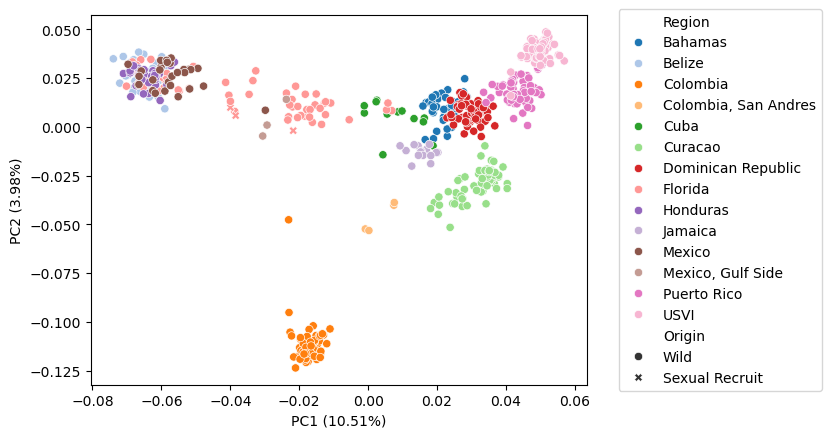

In [198]:
sns.scatterplot(data = eigen.sort_values("Region").reset_index(drop=True), 
                x = "PC1", y = "PC2", hue = "Region", palette = "tab20", style = "Origin")
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.xlabel("PC1 (" + str(round(eigenval[0][0], 2)) + "%)")
plt.ylabel("PC2 (" + str(round(eigenval[0][1], 2)) + "%)")
plt.savefig("../figures/pca.pdf", dpi = 300)

## Showing the impact of not removing low CONF sites:

In [5]:
%%bash
source ~/.bashrc
conda activate orbicella
bcftools view -i 'F_MISSING<0.1' ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3.vcf.gz \
    -Oz > ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf.vcf.gz

In [6]:
%%bash
source ~/.bashrc
conda activate orbicella
plink2 --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf.vcf.gz \
    --missing --out ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf.log.
Options in effect:
  --missing
  --out ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf
  --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf.vcf.gz

Start time: Wed Apr 29 16:14:15 2026
771373 MiB RAM detected, ~695956 available; reserving 385686 MiB for main
workspace.
Using up to 8 compute threads.
--vcf: 18820 variants scanned.
--vcf: 9k variants converted.  
../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf-temporary.pgen +
../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf-temporary.pvar.zst +
../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf-temporary.psam
written.
1462 samples (0 females, 0 males, 1462 ambiguous; 1462 founders) loaded from
../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf-tem

In [9]:
imiss = pd.read_csv("../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf.smiss", sep = "\t").sort_values("F_MISS")

In [13]:
imiss[["#IID"]][imiss["F_MISS"] > 0.05].to_csv("../filtered_calls/noconf_exclude_samples.txt", header = None, index = False)

In [16]:
%%bash
source ~/.bashrc
conda activate orbicella
bcftools view -S ^../filtered_calls/noconf_exclude_samples.txt \
    ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf.vcf.gz -O z \
    > ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf_indvmissfiltered.vcf.gz

In [17]:
%%bash
source ~/.bashrc
conda activate orbicella
plink2 --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf_indvmissfiltered.vcf.gz \
    --make-king-table --out noconf_kin

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to noconf_kin.log.
Options in effect:
  --make-king-table
  --out noconf_kin
  --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf_indvmissfiltered.vcf.gz

Start time: Wed Apr 29 16:16:17 2026
771373 MiB RAM detected, ~695861 available; reserving 385686 MiB for main
workspace.
Using up to 8 compute threads.
--vcf: 18820 variants scanned.
--vcf: noconf_kin-temporary.pgen + noconf_kin-temporary.pvar.zst +
noconf_kin-temporary.psam written.
1461 samples (0 females, 0 males, 1461 ambiguous; 1461 founders) loaded from
noconf_kin-temporary.psam.
Note: 14 nonstandard chromosome codes present.
18820 variants loaded from noconf_kin-temporary.pvar.zst.
Note: No phenotype data present.
--make-king-table pass 1/1: Scanning for rare variants... done.
10319 variants handled by initial scan (8501 remaining).
--make-king-tabl

In [18]:
%%bash
source ~/.bashrc
conda activate orbicella
plink2 --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf_indvmissfiltered.vcf.gz \
    --king-cutoff 0.08834 --out noconf_kin

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to noconf_kin.log.
Options in effect:
  --king-cutoff 0.08834
  --out noconf_kin
  --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf_indvmissfiltered.vcf.gz

Start time: Wed Apr 29 16:16:20 2026
771373 MiB RAM detected, ~695861 available; reserving 385686 MiB for main
workspace.
Using up to 8 compute threads.
--vcf: 18820 variants scanned.
--vcf: noconf_kin-temporary.pgen + noconf_kin-temporary.pvar.zst +
noconf_kin-temporary.psam written.
1461 samples (0 females, 0 males, 1461 ambiguous; 1461 founders) loaded from
noconf_kin-temporary.psam.
Note: 14 nonstandard chromosome codes present.
18820 variants loaded from noconf_kin-temporary.pvar.zst.
Note: No phenotype data present.
--king-cutoff pass 1/1: Scanning for rare variants... done.
10320 variants handled by initial scan (8500 remaining).
--king-cutoff pa

Two samples get malformed names coming out of plink because of a whitespace (not supposed to be any whitespaces in STAGdb sample names but people make errors)...I'm going fix those here:

In [19]:
!zcat ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf_indvmissfiltered.vcf.gz | grep "^#" | tail -1 | sed "s/\t/\n/g" | grep "Sarah"

Sarah 1_(Axiom_AcropSNP)_K07.CEL


In [20]:
!cat noconf_kin.king.cutoff.in.id | grep "Sarah"

Sarah


In [21]:
!sed "s/Sarah/Sarah 1_(Axiom_AcropSNP)_K07.CEL/g" noconf_kin.king.cutoff.in.id > fixed_noconf_kin.king.cutoff.in.id

Also going to check for samples with anomalous heterozygosity and remove them if needed:

In [22]:
%%bash
source ~/.bashrc
conda activate orbicella
vcftools --gzvcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf_indvmissfiltered.vcf.gz \
    --het --out ../filtered_calls/het_noconf


VCFtools - 0.1.16
(C) Adam Auton and Anthony Marcketta 2009

Parameters as interpreted:
	--gzvcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf_indvmissfiltered.vcf.gz
	--het
	--out ../filtered_calls/het_noconf

Using zlib version: 1.2.13
After filtering, kept 1461 out of 1461 Individuals
Outputting Individual Heterozygosity
	Individual Heterozygosity: Only using biallelic SNPs.
After filtering, kept 18820 out of a possible 18820 Sites
Run Time = 7.00 seconds


In [26]:
het = pd.read_csv("../filtered_calls/het_noconf.het", sep = "\t")
het["HET"] = (het["N_SITES"] - het["O(HOM)"]) / het["N_SITES"]

In [24]:
het[["INDV"]][het["HET"] < (het.HET.mean() - (het.HET.std()*3))].to_csv("../low_het_samps_noconf.txt", header = None, index = False)

In [27]:
!grep -v -f ../low_het_samps_noconf.txt \
    fixed_noconf_kin.king.cutoff.in.id \
    > fixed_noconf_kin_nolowhet_plink2.king.cutoff.in.id

In [29]:
allmeta = pd.read_csv("../030426_all_sample_data.tabular", sep = "\t")
allmeta.loc[allmeta["Reef Name"] == "Veracruz", "Region"] = "Mexico" #Veracruz is in Mexico, not Belize...
allmeta = (allmeta
 [allmeta["Genetic Coral Species Call"] == "A.palmata"] # Only extracting APAL
 [~allmeta["User Specimen ID"].str.contains("SWSA")] #selfed samples from CU
 [allmeta["Region"] != "State College"] # State College implies uncertain or unknown location data, because we don't have Apal in State College...
 [allmeta["Coral Mlg Clonal ID"] != "HG1212"] #This sample has been shown to be wonky - a genet that spans FL and Cuba - Probably some mislabeling?
 [~allmeta["Affymetrix ID"].str.contains("a100000")]).reset_index(drop=True) #Seq derived samples - Often stand out on their own and should be removed

/fs/s6k/fast/scratch/16475825_noge4093_mpcs055/ipykernel_237422/698802026.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  allmeta = (allmeta
/fs/s6k/fast/scratch/16475825_noge4093_mpcs055/ipykernel_237422/698802026.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  allmeta = (allmeta
/fs/s6k/fast/scratch/16475825_noge4093_mpcs055/ipykernel_237422/698802026.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  allmeta = (allmeta
/fs/s6k/fast/scratch/16475825_noge4093_mpcs055/ipykernel_237422/698802026.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  allmeta = (allmeta


In [30]:
allmeta["#IID"] = allmeta["Affymetrix ID"].copy()

In [31]:
samplelist = pd.read_csv("fixed_noconf_kin_nolowhet_plink2.king.cutoff.in.id").merge(allmeta, how = "left", on = "#IID")

In [32]:
samplelist.loc[samplelist["Region"].isna(), "Region"] = "USVI"

In [33]:
df = samplelist.copy()

In [36]:
seed = 42
rng = np.random.default_rng(seed)

df_shuffled = df.sample(frac=1, random_state=seed)

df_shuffled["site_rank"] = (
    df_shuffled.groupby(["Region", "Reef Name"])
    .cumcount()
)

# sort so we take 1 per site first, then 2nd per site, etc.
df_sorted = df_shuffled.sort_values(["Region", "site_rank"])

# take up to 60 per region
sampled_df = (
    df_sorted.groupby("Region", group_keys=False)
    .head(60)
    .drop(columns="site_rank")
    .reset_index(drop=True)
)

In [37]:
sampled_df[["#IID"]].to_csv("../downsamples_samples_no_conf.id", index = False)

In [38]:
%%bash
source ~/.bashrc
conda activate orbicella
bcftools view ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf_indvmissfiltered.vcf.gz \
    -S ../downsamples_samples_no_conf.id --force-samples \
    | bcftools view -q 0.05:minor \
    -m2 -M2 -v snps \
    | bcftools +prune -m 0.5 -w 100000 -Oz \
    > ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf_indvmissfiltered_maffiltered.vcf.gz

Warn: subset called for sample that does not exist in header: "#IID"... skipping


In [40]:
%%bash
source ~/.bashrc
conda activate orbicella
plink2 --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf_indvmissfiltered_maffiltered.vcf.gz \
    --pca 200 --out no_conf

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to no_conf.log.
Options in effect:
  --out no_conf
  --pca 200
  --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_noconf_indvmissfiltered_maffiltered.vcf.gz

Start time: Wed Apr 29 16:20:58 2026
771373 MiB RAM detected, ~692073 available; reserving 385686 MiB for main
workspace.
Using up to 8 compute threads.
--vcf: 3468 variants scanned.
--vcf: no_conf-temporary.pgen + no_conf-temporary.pvar.zst +
no_conf-temporary.psam written.
555 samples (0 females, 0 males, 555 ambiguous; 555 founders) loaded from
no_conf-temporary.psam.
Note: 14 nonstandard chromosome codes present.
3468 variants loaded from no_conf-temporary.pvar.zst.
Note: No phenotype data present.
Calculating allele frequencies... done.
Constructing GRM: 12162024293337414549535862667074788387919599done.
Correcting for missingness... 101621263237424853586

In [42]:
eigen = pd.read_csv("no_conf.eigenvec", sep = "\t")

In [43]:
eigenval = pd.read_csv("no_conf.eigenval", header = None)

In [44]:
eigenval[0] = (eigenval[0] / eigenval[0].sum()) * 100

In [45]:
eigen.loc[eigen["#IID"] == "Sarah", "#IID"] = "Sarah 1_(Axiom_AcropSNP)_K07.CEL"
eigen.loc[eigen["#IID"] == "AP40", "#IID"] = "AP40 11.7.22_(Axiom_AcropSNP)_O23.CEL"

In [46]:
eigen = eigen.merge(samplelist, how = "left", on = "#IID")

In [47]:
eigen.loc[eigen["Reef Name"] == "Alacranes", "Region"] = "Mexico, Gulf Side"
eigen.loc[eigen["Reef Name"] == "Veracruz", "Region"] = "Mexico, Gulf Side"
eigen.loc[eigen["Reef Name"] == "Serrana", "Region"] = "Colombia, San Andres"
eigen.loc[eigen["Reef Name"] == "Roncador", "Region"] = "Colombia, San Andres"

In [48]:
eigen["PC2"] = eigen["PC2"] * -1

In [49]:
eigen["PC1"] = eigen["PC1"] * -1

In [50]:
eigen.loc[eigen["Reef Name"].isna(), "Reef Name"] = "NAN"

In [51]:
eigen["Origin"] = "Wild"
eigen.loc[eigen["Reef Name"].str.contains("batch", case = False), "Origin"] = "Sexual Recruit"
eigen.loc[eigen["Reef Name"].str.contains("cross", case = False), "Origin"] = "Sexual Recruit"
eigen.loc[eigen["Reef Name"].str.contains("sexual", case = False), "Origin"] = "Sexual Recruit"
eigen.loc[eigen["Reef Name"].str.contains("recruit", case = False), "Origin"] = "Sexual Recruit"

In [53]:
import matplotlib.pyplot as plt

In [55]:
eigen["PC2"] = eigen["PC2"] * -1

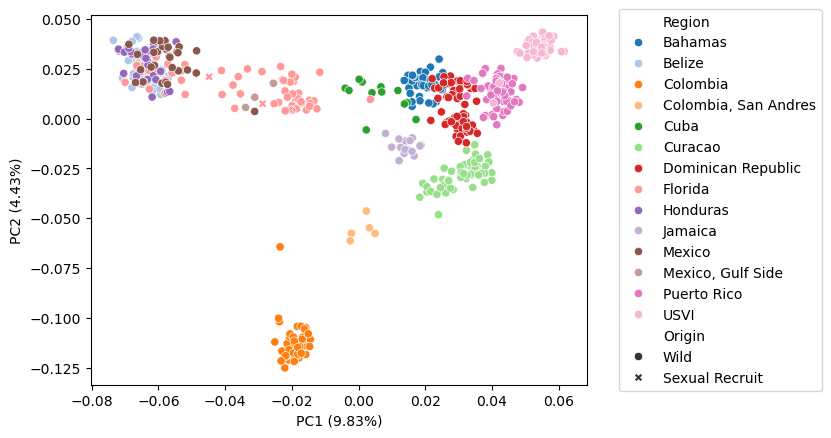

In [57]:
sns.scatterplot(data = eigen.sort_values("Region").reset_index(drop=True), 
                x = "PC1", y = "PC2", hue = "Region", palette = "tab20", style = "Origin")
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.xlabel("PC1 (" + str(round(eigenval[0][0], 2)) + "%)")
plt.ylabel("PC2 (" + str(round(eigenval[0][1], 2)) + "%)")
plt.savefig("../figures/FigS2.pdf", dpi = 300)